In [ ]:
import torch
import os
import matplotlib.pyplot as plt
from transformers import LlamaConfig,LlamaTokenizer,AutoTokenizer
import numpy as np

In [ ]:
model_path = "path to model"
model_config = LlamaConfig.from_pretrained(model_path)

In [3]:
#list of hyper parameters
D = model_config.hidden_size #full hidden dimension D=h*d
h = model_config.num_attention_heads #number of attention heads
hkv = model_config.num_key_value_heads #number of key/values heads, will be smaller than h if GQA
d = model_config.head_dim
L = model_config.num_hidden_layers

In [2]:
def save_error(error, filename):
    path = os.path.join(os.environ["SCRATCH"],filename)
    torch.save(torch.tensor(error),path)

def load_error(filename):
    path = os.path.join(os.environ["SCRATCH"],filename)
    return torch.load(path).tolist()

In [3]:
data_alpha = []
data_alpha.append(np.mean(np.array(load_error("error_llama2_7B_SVDEigen_valdata32_2048_C4.pt")[6])))
for alpha in range(2,11):
    error_eigen = load_error("error_llama2_7B_SVDEigen_valdata32_2048_C4_"+str(alpha)+".pt")
    data_alpha.append(np.mean(np.array(error_eigen[6])))
print(data_alpha)
value_kqt = np.mean(np.array(load_error("error_llama2_7B_KQT_valdata32_2048_C4.pt")[6]))
print(value_kqt)
value_svd = np.mean(np.array(load_error("error_llama2_7B_SVD_valdata32_2048_C4.pt")[6]))
print(value_svd)

[np.float64(0.2836725115776062), np.float64(0.2904232144355774), np.float64(0.2971764802932739), np.float64(0.32580506801605225), np.float64(0.3496054410934448), np.float64(0.3610551357269287), np.float64(0.3675386905670166), np.float64(0.37219858169555664), np.float64(0.3763214349746704), np.float64(0.377427339553833)]
0.26840323209762573
0.3794546127319336


/tmp/ipykernel_2743923/2150126775.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(path).tolist()


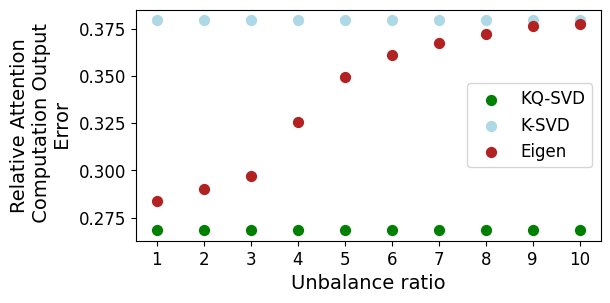

In [ ]:

# Define minimum and maximum
y_min = value_kqt
y_max = value_svd
size = 50

# Generate some x values
x = np.arange(1, 11)
plt.xticks(x)

fs = 14
# Generate random y values between y_min and y_max
y = data_alpha

plt.rcParams.update({'font.size': 12})

# Plot horizontal lines
plt.scatter(x, [y_min for _ in range(10)],s=size, color='green', zorder=5, label='KQ-SVD')
plt.scatter(x, [y_max for _ in range(10)],s=size, color='lightblue', zorder=5, label='K-SVD')

# Plot points
plt.scatter(x, y,s=size, color='firebrick', zorder=5, label='Eigen')

# Labels and legend
plt.xlabel("Unbalance ratio",fontsize=fs)
plt.ylabel("Relative Attention\n Computation Output\n Error ",fontsize=fs)
fig = plt.gcf()              # get current figure
fig.set_size_inches(6, 3) 
plt.legend()
plt.savefig("llama2_7B_varying_alpha.pdf", bbox_inches='tight')
plt.show()


In [ ]:
def plotting_all_three_methods_llama8(errors, save=False, save_name=None):

    f, ax = plt.subplots(2, 4, figsize=(20,6))


    colors = {'SVD': 'lightblue', 'Eigen': 'firebrick', 'KQT': 'forestgreen'}
    title = ["Llama2-7B","Llama2-13B","Llama3-8B","Mistral-7B-v0.3"]
    is_log = [False,False,True,True]
    fs = 20
    smallfs=16
    

    for i in range(4):


        L=len(errors[i][0][6])

        ax[0][i].plot(range(1, L+1), errors[i][0][6], color=colors['SVD'], marker="o", label="K-SVD", alpha=0.7)
        ax[0][i].plot(range(1, L+1), errors[i][1][6], color=colors['Eigen'], marker="o", label="Eigen")
        ax[0][i].plot(range(1, L+1), errors[i][2][6], color=colors['KQT'], marker="o", label="KQ-SVD", linewidth=2)
        
        if i==0:
            
            ax[0][i].set_ylabel("Output error\n per layer",fontsize=fs)
        
        ax[0][i].set_title(title[i],fontsize=fs)
        
        ax[0][i].grid(True, alpha=0.3)

        if is_log[i]:
            ax[0][i].set_yscale('log')

        #BOTTOM PLOTS

        metrics = ['K', 'Q', 'V', 'Attn', 'Output']
        indices = [0, 1, 2, 3, 6]
        
        svd_means1 = [np.mean(errors[i][0][j]) for j in indices]
        eigen_means1 = [np.mean(errors[i][1][j]) for j in indices]
        kqt_means1 = [np.mean(errors[i][2][j]) for j in indices]
        
        x = np.arange(len(metrics))
        width = 0.25
        
        ax[1][i].bar(x - width, svd_means1, width, label='K-SVD', color=colors['SVD'], alpha=0.7)
        ax[1][i].bar(x, eigen_means1, width, label='Eigen', color=colors['Eigen'], alpha=0.8)
        ax[1][i].bar(x + width, kqt_means1, width, label='KQ-SVD', color=colors['KQT'], alpha=0.9)

        if i==0:
            ax[1][i].set_ylabel('Mean\n Relative Error\n Across Layers',fontsize=fs)
        ax[1][i].set_xticks(x)

        ax[1][i].set_xticklabels(metrics,fontsize=smallfs)
        rotations = [0, 0, 0, 45, 45]
        for label, angle in zip(ax[1][i].get_xticklabels(), rotations):
            label.set_rotation(angle)
        
        ax[1][i].grid(True, alpha=0.3)
        ax[1][i].set_yscale('log')
        if i==3:
            ax[0][i].legend(fontsize=12)
            ax[1][i].legend(fontsize=12)

    ymin1 = min([ax[1][i].get_ylim()[0] for i in range(4)])
    ymax1 = max([ax[1][i].get_ylim()[1] for i in range(4)])
    ymin0 = min([ax[0][i].get_ylim()[0] for i in range(2)])
    ymax0 = max([ax[0][i].get_ylim()[1] for i in range(2)])
    for i in range(4):
        ax[1][i].set_ylim(ymin1, ymax1)

    for i in range(2):
        ax[0][i].set_ylim(ymin0, ymax0)
    ymin0 = min([ax[0][i].get_ylim()[0] for i in range(2,4)])
    ymax0 = max([ax[0][i].get_ylim()[1] for i in range(2,4)])
    for i in range(2,4):
        ax[0][i].set_ylim(ymin0, ymax0)

    if save:
        f.savefig("all_plots.pdf", bbox_inches='tight')


    plt.show()

In [ ]:
errors = [[load_error("error_llama2_7B_SVD_valdata32_2048_C4.pt"),load_error("error_llama2_7B_SVDEigen_valdata32_2048_C4.pt"),load_error("error_llama2_7B_KQT_valdata32_2048_C4.pt")],
          [load_error("error_llama2_13B_SVD_valdata32_2048_C4.pt"),load_error("error_llama2_13B_SVDEigen_valdata32_2048_C4.pt"),load_error("error_llama2_13B_KQT_valdata32_2048_C4.pt")],
          [load_error("error_llama3_8B_SVD_valdata16_4096_C4_stack.pt"),load_error("error_llama3_8B_SVDEigen_valdata16_4096_C4_stack.pt"),load_error("error_llama3_8B_KQT_valdata16_4096_C4_stack.pt")],
          [load_error("error_Mistral_7B_SVD_traindata32_2048_C4_stack.pt"),load_error("error_Mistral_7B_SVDEigen_traindata32_2048_C4_stack.pt"),load_error("error_Mistral_7B_KQT_traindata32_2048_C4_stack.pt")]]

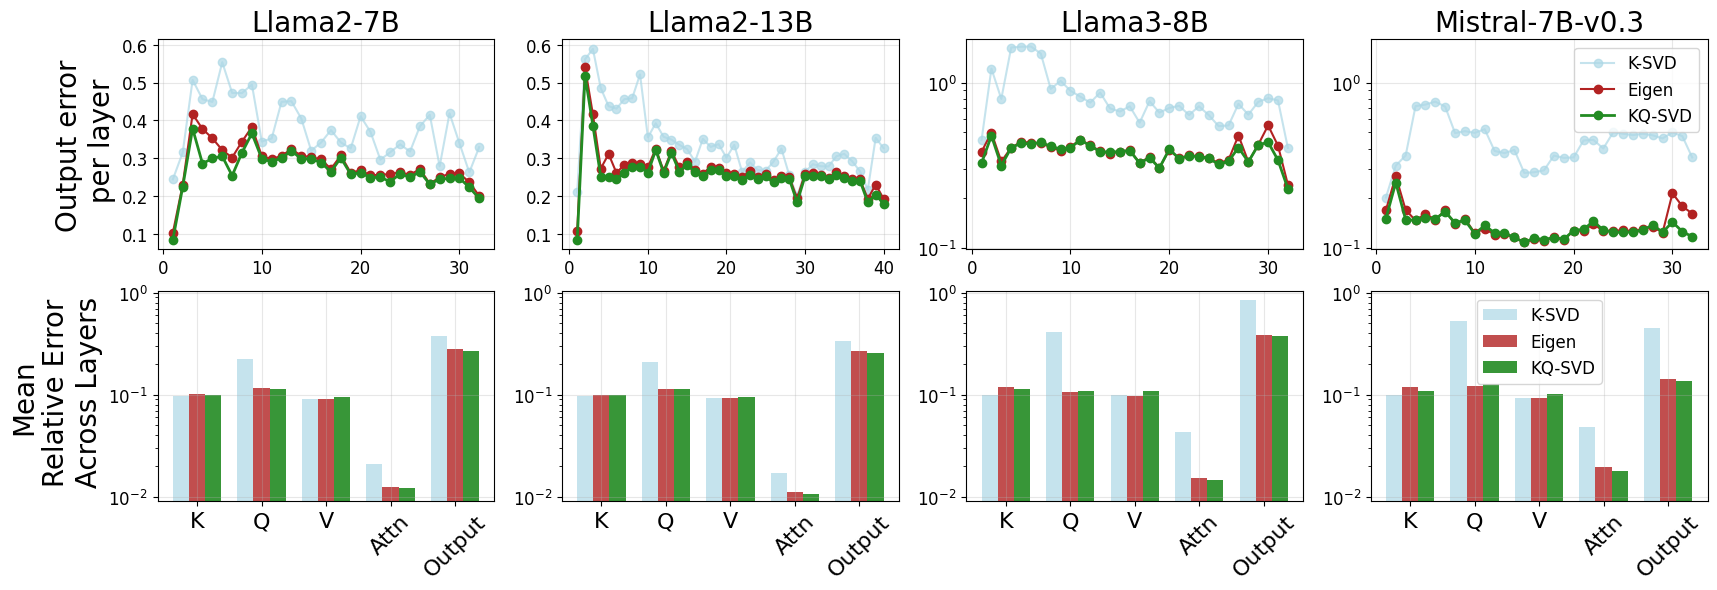

In [22]:
plotting_all_three_methods_llama8(errors, save=True, save_name=None)